Import Libraries

In [1]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Set visualization style
sns.set_theme(style="whitegrid")

In [3]:
# Load the dataset (make sure you uploaded Titanic-Dataset.csv to Colab)
df = pd.read_csv('Titanic-Dataset.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Dataset Shape: (891, 12)

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# 1. Feature Engineering: Create FamilySize
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# 2. Handle Missing Values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# 3. Encode Categorical Variable: Sex (male -> 0, female -> 1)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# 4. Select only the required features and target variable
features = ['Pclass', 'Sex', 'Age', 'Fare', 'FamilySize']
X = df[features]
y = df['Survived']

print("Features prepared successfully.")
print("Missing values remaining:", X.isnull().sum().sum())

Features prepared successfully.
Missing values remaining: 0


/tmp/ipykernel_10855/1612675673.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, ax=axes[0], palette='Set2')
/tmp/ipykernel_10855/1612675673.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Did Not Survive (0)', 'Survived (1)'])


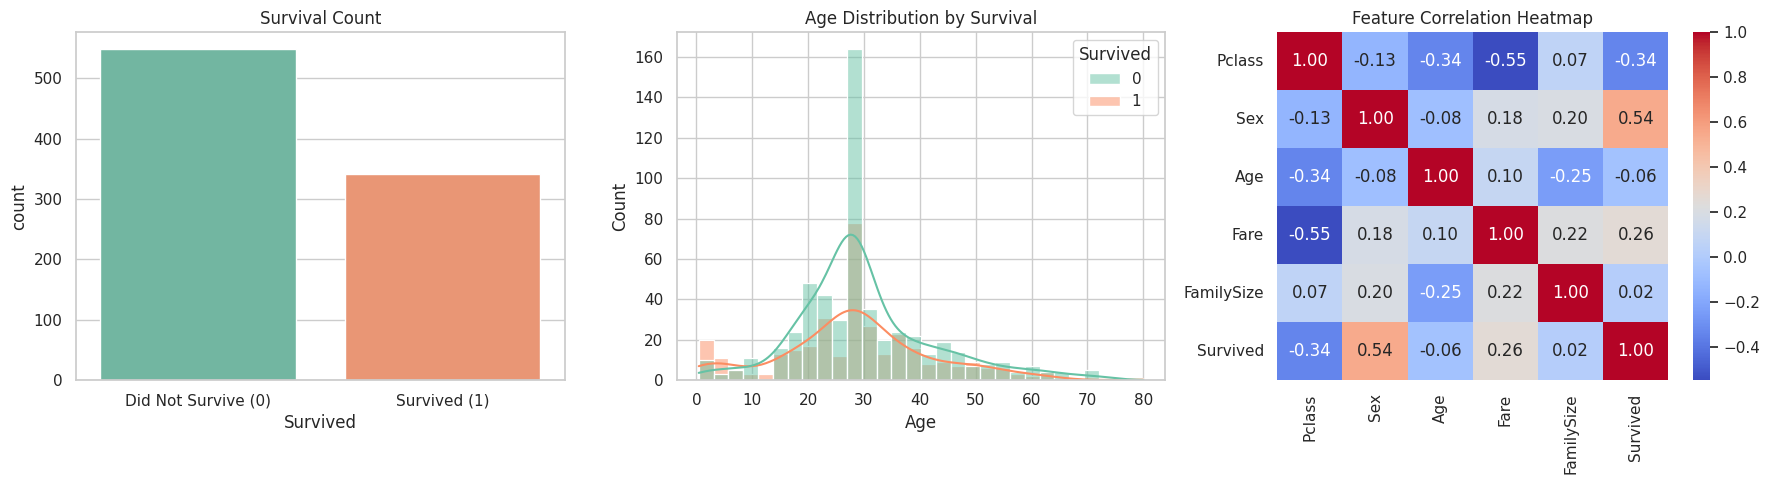

In [5]:
# Create a 1x3 figure for all required plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# . Survival Count Bar Plot
sns.countplot(x='Survived', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Survival Count')
axes[0].set_xticklabels(['Did Not Survive (0)', 'Survived (1)'])

# . Age Distribution Histogram (by survival)
sns.histplot(data=df, x='Age', hue='Survived', kde=True, bins=30, ax=axes[1], palette='Set2')
axes[1].set_title('Age Distribution by Survival')

# . Correlation Heatmap
sns.heatmap(df[features + ['Survived']].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[2])
axes[2].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

#  TIP: Right-click any plot in Colab and select "Save image as..." to get your screenshots.

In [6]:
# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 712
Testing set size: 179


In [7]:
# Initialize and train the model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

print(" Logistic Regression model trained successfully.")

 Logistic Regression model trained successfully.


📊 Model Accuracy: 81.01%

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       110
           1       0.77      0.72      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



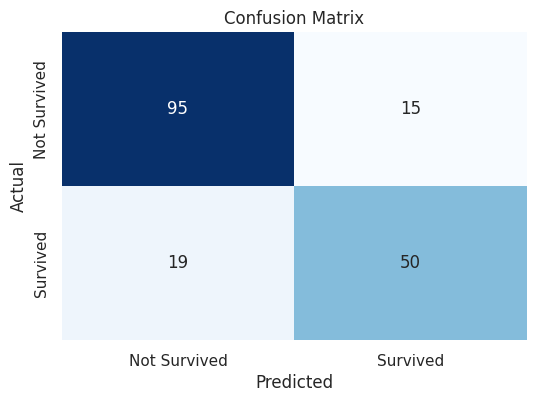

In [8]:
# Make predictions
y_pred = model.predict(X_test_scaled)

# Calculate Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"📊 Model Accuracy: {acc:.2%}")

# Print Classification Report
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [9]:
#  Save Model & Scaler
import joblib
from google.colab import files

# Save the trained model and the fitted scaler
joblib.dump(model, 'titanic_logreg_model.pkl')
joblib.dump(scaler, 'titanic_scaler.pkl')

print(" Model and scaler saved successfully!")

# Download to your local machine (Colab deletes files when the session ends)
files.download('titanic_logreg_model.pkl')
files.download('titanic_scaler.pkl')

 Model and scaler saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>